# Category & Promo Analytics для онлайн-ритейла

## Анализ продаж, промо-доли, маржинальности и ABC-сегментации по категориям и подкатегориям

### Бизнес-цель

Оценить структуру продаж по товарным категориям онлайн-ритейла, выявить ключевые драйверы объёма и выручки, оценить влияние промо на категорию «Сыры» и маржинальность ассортимента для приоритизации категорийного менеджмента.

### Аналитические задачи 
1. Определить категорию с наибольшим объёмом продаж.
2. Описать распределение продаж внутри категорий по подкатегориям.
3. Рассчитать средний чек за 13.01.2022.
4. Оценить долю промо-продаж в категории «Сыры».
5. Посчитать маржу по категориям (руб. и %).
6. Провести ABC-анализ подкатегорий по объёму и по выручке, сформировать итоговую матрицу сегментов.

### Ограничения и допущения 
- Анализ по штукам и выручке — только для товаров, присутствующих в справочнике products.
- Промо определяется как `price < regular_price`.
- ABC — на уровне subcategory (подкатегории).
- Период данных: 13.01.2022 (один день).

### Описание данных

Таблица `products`:
- `product_id` — id товара
- `category` — товарная категория (в исходнике: `level1`)
- `subcategory` — подкатегория (в исходнике: `level2`)
- `name` — наименование товара

Таблица `orders`:
- `order_id` — номер чека
- `accepted_at` — дата и время чека
- `product_id` — id товара
- `quantity` — кол-во товара в чеке
- `regular_price` — регулярная цена
- `price` — текущая цена
- `cost_price` — закупочная цена

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
orders = pd.read_excel('data/orders.xlsx')
products = pd.read_excel('data/products.xlsx')

products = products.rename(columns={
    'level1': 'category',
    'level2': 'subcategory',
})

### Первичный обзор данных

Смотрим каждую таблицу отдельно: структуру, пропуски и ключевые проверки

#### Таблица `orders`

In [3]:
orders.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130


In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3323 non-null   int64         
 1   accepted_at    3323 non-null   datetime64[us]
 2   product_id     3323 non-null   int64         
 3   quantity       3323 non-null   int64         
 4   regular_price  3323 non-null   int64         
 5   price          3323 non-null   int64         
 6   cost_price     3323 non-null   int64         
dtypes: datetime64[us](1), int64(6)
memory usage: 181.9 KB


In [5]:
orders.describe()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
count,3.323000e+03,3323,3323.000000,3323.00000,3323.000000,3323.000000,3323.000000
mean,1.517529e+09,2022-01-13 16:02:37.557628,22961.379175,1.23533,139.828167,130.645501,81.106229
min,1.517207e+09,2022-01-13 08:00:30,23.000000,1.00000,11.000000,4.000000,7.000000
25%,1.517454e+09,2022-01-13 12:50:33,6008.000000,1.00000,77.000000,72.000000,42.000000
50%,1.517524e+09,2022-01-13 16:26:22,12114.000000,1.00000,117.000000,109.000000,67.000000
75%,1.517605e+09,2022-01-13 19:22:00,30321.500000,1.00000,179.000000,165.000000,101.000000
max,1.517855e+09,2022-01-13 22:58:29,120497.000000,12.00000,1797.000000,1797.000000,808.000000
std,1.029182e+05,NaN,25476.196162,0.78861,104.195194,96.328751,61.505484


In [6]:
orders['order_id'].nunique()

544

**Вывод `orders`:** 
- Таблица без пропусков
- Данные представленны за один день `13.01.2022`
- Кол-во уникальных заказов - 544
- `quantity` и `price` в допустимых значениях (min ≥ 1, отрицательных значений нет)

#### Таблица `products`

In [7]:
products.head()

,product_id,category,subcategory,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...
1,2,Мучные кондитерские изделия,Мучные кондитерские изделия,Печенье Бодрость
2,3,Мясная гастрономия,"Сосиски, сардельки",Сосиски Стародворье
3,4,Чай,Черный чай,Чай Азерчай
4,5,Безалкогольные напитки,Соковая продукция,Морс Valio


In [8]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 40152 entries, 0 to 40151
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   product_id   40152 non-null  int64
 1   category     40152 non-null  str  
 2   subcategory  40152 non-null  str  
 3   name         39940 non-null  str  
dtypes: int64(1), str(3)
memory usage: 1.2 MB


In [9]:
print(f'Уникальных категорий: {products['category'].nunique()}')
print(f'Уникальных податегорий: {products['subcategory'].nunique()}')
print(f'Пропущенных значений в колонке "name": {products['name'].isna().sum()}')

Уникальных категорий: 33
Уникальных податегорий: 168
Пропущенных значений в колонке "name": 212


**Вывод `products`:**
- Дата фрейм пригоден для категорийного анализа
- Пропуски есть только в `name` - на расчёты по категориям не повлияют
- Дубликатов `product_id` нет.

### Подготовка данных для анализа

In [10]:
order_items = orders.merge(products, on='product_id', how='inner')

In [11]:
order_items.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,category,subcategory,name
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат


In [12]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 3018 entries, 0 to 3017
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       3018 non-null   int64         
 1   accepted_at    3018 non-null   datetime64[us]
 2   product_id     3018 non-null   int64         
 3   quantity       3018 non-null   int64         
 4   regular_price  3018 non-null   int64         
 5   price          3018 non-null   int64         
 6   cost_price     3018 non-null   int64         
 7   category       3018 non-null   str           
 8   subcategory    3018 non-null   str           
 9   name           3010 non-null   str           
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 235.9 KB


Настройки для графиков

In [13]:
plt.rcParams.update({
    "figure.figsize": (16, 8),      
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,           
    "grid.alpha": 0.3,
})

Метод для построения графиков

In [14]:
def plot_chart(
    df,
    kind="bar",
    x=None,
    y=None,
    title="",
    xlabel="",
    ylabel="",
    legend=False,
    ax=None,
    show=True,
    **kwargs,          # color, rot, stacked
):
    own_figure = ax is None

    ax = df.plot(
        kind=kind,
        x=x,
        y=y,
        legend=legend,
        ax=ax,
        **kwargs,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if own_figure:
        plt.tight_layout()
        if show:
            plt.show()

    return ax

### 1. Категории товаров с наибольшим объёмом продаж

In [15]:
sales_by_category_df = order_items.groupby('category', as_index=False) \
                    .agg(units_category=('quantity', 'sum')) \
                    .sort_values('units_category')

In [16]:
sales_by_category_df.head()


,category,units_category
22,Специальное питание,2
5,Детство (Гигиена и Уход),6
17,Рыба,8
9,"Кофе, какао",21
2,Бытовая химия,23


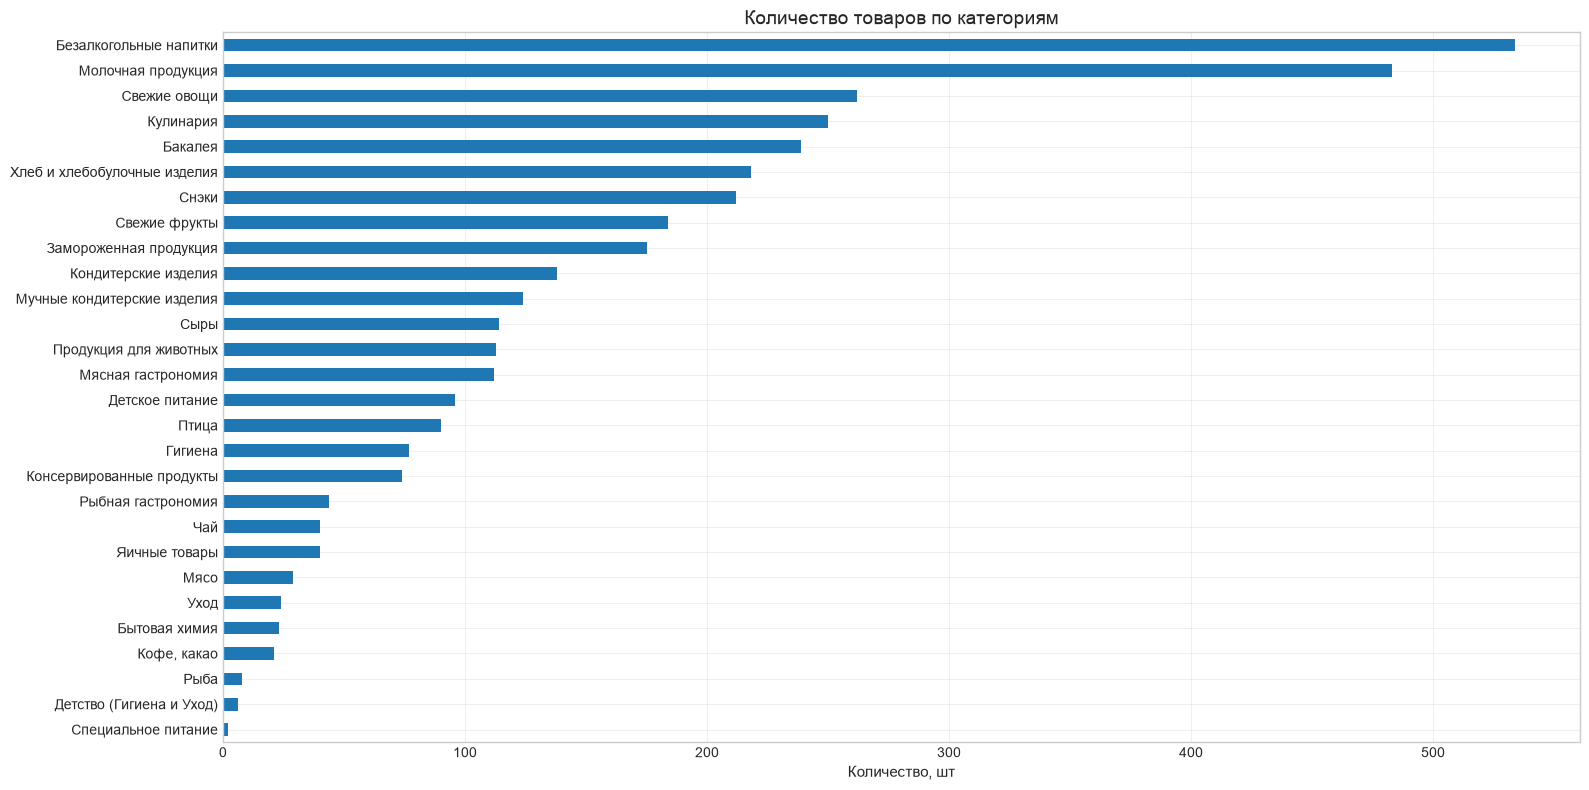

<Axes: title={'center': 'Количество товаров по категориям'}, xlabel='Количество, шт'>

In [17]:
plot_chart(
  sales_by_category_df,
  kind='barh',
  x="category", 
  y="units_category",
  title="Количество товаров по категориям",
  xlabel="Количество, шт"
)

In [18]:
all_categories = set(products["category"])
sold_categories = set(order_items["category"])
no_sales = sorted(all_categories - sold_categories)
no_sales

['Не распределено',
 'Парфюмерия и декоративная косметика',
 'Промышленные товары',
 'Рынок',
 'Табачные изделия']

#### Вывод:

- Продажи сильно сконцентрированы в двух категориях: `безалкогольные напитки` и `молочная продукция`. Две первые категории по объёму почти равны следующим пяти–шести вместе.

- Дальше идут повседневные продукты, которые покупают часто: `овощи`, `кулинария`, `бакалея`, `хлеб`, `снэки`, `фрукты`. Вместе с топом это основной набор категорий, на который приходится большая часть продаж.

- Внизу списка — `рыба`, `детская гигиена` и `спецпитание`: продаж очень мало. Причины могут быть разные - мало товаров в наличии или просто низкий спрос. Это стоит проверить отдельно.

- За день покупки были в `28` из `33` категорий. Без продаж: `Не распределено`, `Парфюмерия и декоративная косметика`, `Промышленные товары`, `Рынок`, `Табачные изделия`. Это не обязательно «мёртвые» категории — за один день их могли просто не купить.

**Что делать**: продвигать топовые товары и следить что бы он был в наличии. По слабым не спешить с решениями, сначала нужно понять, почему так мало продаж, и только потом принимать решение.

### 2. Распределение продаж внутри категорий по подкатегориям


Для начала вычислим какое количество товаров продовалось в каждой подкатегори


In [19]:
subcategory_sales_df = order_items.groupby(['category', 'subcategory'], as_index=False) \
                      .agg(units_subcategory = ('quantity', 'sum'))                     


Присоединим к таблице `subcategory_sales_df` общий объём по категории из `sales_by_category_df`, чтобы потом считать долю внутри category.


In [20]:
subcategory_sales_df = subcategory_sales_df.merge(sales_by_category_df, on='category', how='inner') 


Добавим `share_pct`, долю продаж подкатегории внутри своей категории, в процентах.


In [21]:
subcategory_sales_df['share_pct'] = (
    subcategory_sales_df['units_subcategory'] / subcategory_sales_df['units_category'] * 100
).round(2)

In [22]:
subcategory_sales_df = subcategory_sales_df.sort_values(
    ['category', 'units_subcategory'],
    ascending=[True, False],
)
subcategory_sales_df


,category,subcategory,units_subcategory,units_category,share_pct
10,Бакалея,Сухие блюда быстрого приготовления,38,239,15.90
3,Бакалея,"Крупы, бобовые",30,239,12.55
1,Бакалея,Зерновые для завтраков,24,239,10.04
4,Бакалея,Макаронные изделия,24,239,10.04
9,Бакалея,Соусы,24,239,10.04
...,...,...,...,...,...
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218,218,100.00
98,Чай,Черный чай,26,40,65.00
96,Чай,Зеленый чай,7,40,17.50
97,Чай,Чайные напитки,7,40,17.50


#### Вывод

- Внутри категорий структура разная: где-то продажи размазаны по многим подкатегориям, где-то почти всё держит один лидер.
- В `Бакалее` (239 шт.) лидер — сухие блюда быстрого приготовления (~16%), дальше крупы (~13%) и ещё несколько групп около 10%. Явного монополиста нет.
- В `Чае` (40 шт.) концентрация сильнее: чёрный чай ~65%, зелёный и чайные напитки — по ~17.5%.
- В крупных категориях вроде `Безалкогольные напитки` и `Молочная продукция` тоже нет одного subcategory на 80%+: лидеры примерно 30–47%.
- В `Кулинарии` почти всё ушло в «Готовые блюда» (~99%). Это важно видеть в расчётной таблице, но не всегда значит «вечную» концентрацию — за один день структура может быть узкой.
- Для бизнеса: смотреть не только топ category, но и кто внутри тянет объём — от этого зависит приоритет наличия.


### 3. Рассчитать средний чек за 13.01.2022

In [23]:
revenue_by_order_df = orders.copy()
revenue_by_order_df['line_revenue'] = revenue_by_order_df['quantity'] * revenue_by_order_df['price']

In [24]:
order_totals_df = revenue_by_order_df.groupby('order_id', as_index=False) \
                      .agg(order_total=('line_revenue', 'sum'))

order_totals_df.head()

,order_id,order_total
0,1517207363,795
1,1517288545,364
2,1517293568,1715
3,1517302077,2096
4,1517305540,342


In [25]:
average_check = order_totals_df['order_total'].mean().round(2)
average_check

np.float64(915.64)

#### Вывод

Средний чек за 13.01.2022 — **915.64 руб.** на основе **544** уникальных заказов.

### 4. Оценить долю промо-продаж в категории «Сыры».

Сначала выделим все продажи категории `Сыры` и посчитаем общий объём продаж по штукам и по выручке.

In [26]:
cheese_items_df = order_items.query("category == 'Сыры'")
total_units = cheese_items_df['quantity'].sum()
total_revenue = (cheese_items_df['quantity'] * cheese_items_df['price']).sum()

Затем отберём только промо-продажи в категории `Сыры`. Промо определяем как `price` < `regular_price`, то есть продажа по цене ниже регулярной.

In [27]:
cheese_promo_items_df = cheese_items_df.query("price < regular_price")
promo_units = cheese_promo_items_df['quantity'].sum()
promo_revenue = (cheese_promo_items_df['quantity'] * cheese_promo_items_df['price']).sum()

Рассчитаем долю промо-продаж в категории `Сыры`, отдельно по штукам и по выручке.

In [28]:
promo_share_units_pct = (promo_units / total_units * 100).round(2)
promo_share_revenue_pct = (promo_revenue / total_revenue * 100).round(2)

In [29]:
print(f'Вклад по штукам: {promo_share_units_pct}')
print(f'Вклад по выручке: {promo_share_revenue_pct}')

Вклад по штукам: 30.7
Вклад по выручке: 23.19


Для наглядной интерпретации результата визуализируем долю промо-продаж в категории Сыры с помощью двух круговых диаграмм.

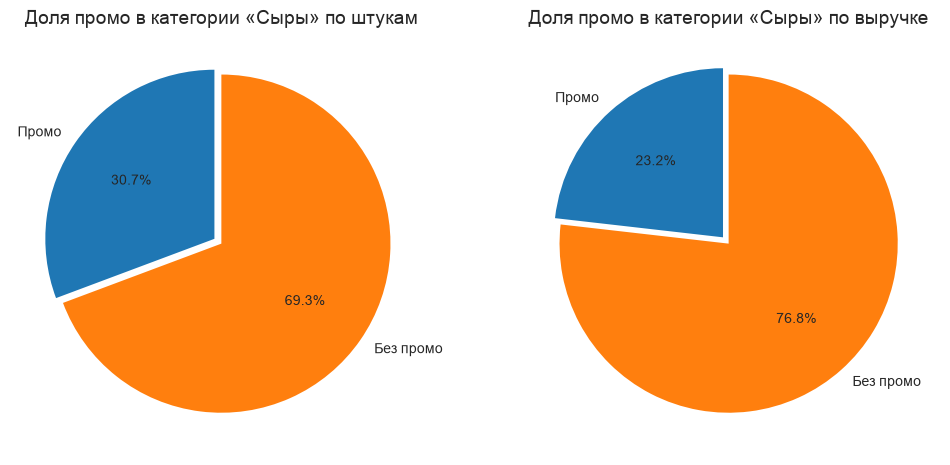

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    [promo_share_units_pct, 100 - promo_share_units_pct],
    labels=['Промо', 'Без промо'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[0].set_title('Доля промо в категории «Сыры» по штукам')

axes[1].pie(
    [promo_share_revenue_pct, 100 - promo_share_revenue_pct],
    labels=['Промо', 'Без промо'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
axes[1].set_title('Доля промо в категории «Сыры» по выручке')

plt.show()

#### Вывод
В категории Сыры доля промо-продаж составила `30.7%` по штукам и `23.19%` по выручке. Промо заметно поддерживает объём продаж в категории, однако его вклад в выручку ниже, чем в количество проданных единиц. Это может означать, что скидки чаще применялись к более дешёвым позициям или к товарам с меньшим вкладом в денежный оборот категории.

### 5. Расчёт маржи по категориям (руб. и %)

Сначала посчитаем маржу и выручку **для каждой строки** `order_items`

- Маржа в рблях: `(price − cost_price) × quantity`
- Выручка: `price × quantity`

In [31]:
order_items_margin = order_items.copy()
order_items_margin['margin_rub'] = (
  (order_items_margin['price'] - order_items_margin['cost_price']) * order_items_margin['quantity']
)
order_items_margin['revenue'] = order_items_margin['price'] * order_items_margin['quantity']

In [32]:
order_items_margin.head()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,category,subcategory,name,margin_rub,revenue
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,95,169
1,1517430051,2022-01-13 16:46:53,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,95,169
2,1517578174,2022-01-13 18:12:30,17122,1,169,169,74,Рыбная гастрономия,Нерыбные продукты моря,Крабовые палочки Меридиан,95,169
3,1517466327,2022-01-13 15:11:12,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,89,219
4,1517429157,2022-01-13 19:15:59,22199,1,219,219,130,Сыры,Мягкие сыры,Сыр Самокат,89,219


Дальше суммируем маржу и выручку **по категориям** и считаем маржинальность

`margin_pct = margin_rub / revenue × 100`

In [33]:
margin_by_category_df = order_items_margin.groupby('category', as_index=False) \
                        .agg({
                          'margin_rub': 'sum',
                          'revenue': 'sum'
                        }) \
                        .sort_values('margin_rub', ascending=False)

margin_by_category_df['margin_pct'] = (
    (margin_by_category_df['margin_rub'] / margin_by_category_df['revenue'] * 100).round(2)
)

In [34]:
margin_by_category_df.head()

,category,margin_rub,revenue,margin_pct
1,Безалкогольные напитки,20373,46107,44.19
10,Кулинария,18452,40840,45.18
6,Замороженная продукция,13099,27714,47.26
11,Молочная продукция,12493,37582,33.24
13,Мясная гастрономия,10230,24150,42.36


Сравним категории по абсолютной марже в рублях и по маржинальности. Первый показатель показывает вклад в общий финансовый результат, второй — долю маржи в выручке категории.

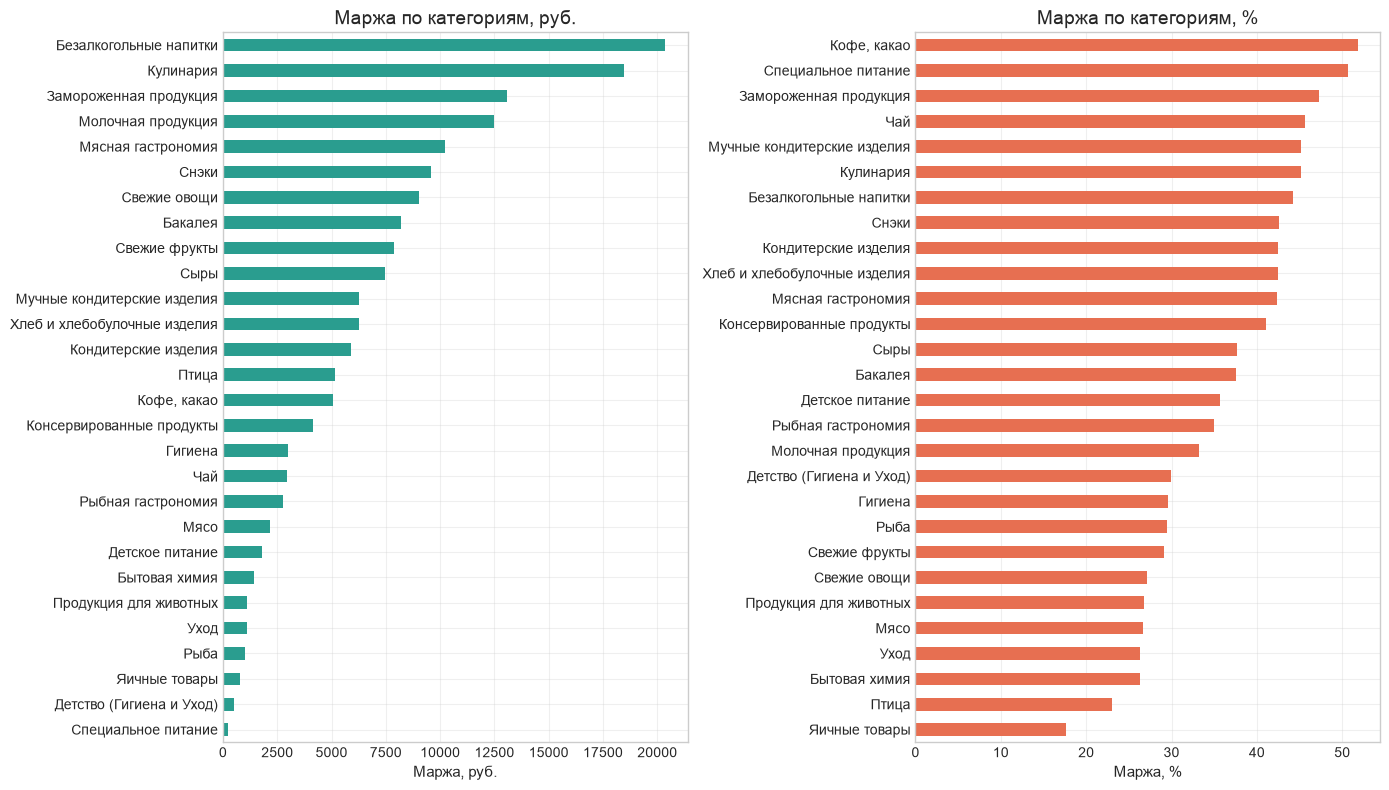

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

plot_chart(
    margin_by_category_df.sort_values('margin_rub'),
    kind='barh',
    x='category',
    y='margin_rub',
    title='Маржа по категориям, руб.',
    xlabel='Маржа, руб.',
    color='#2A9D8F',
    ax=axes[0],
    show=False,
)

plot_chart(
    margin_by_category_df.sort_values('margin_pct'),
    kind='barh',
    x='category',
    y='margin_pct',
    title='Маржа по категориям, %',
    xlabel='Маржа, %',
    color='#E76F51',
    ax=axes[1],
    show=False,
)

plt.tight_layout()
plt.show()

#### Вывод

- По марже в рублях лидируют `безалкогольные напитки`, `кулинария`, `замороженная` и `молочная продукция`. Эти категории дали основной объём маржи за рассматриваемый день, поэтому для них важно поддерживать наличие товаров.

- По маржинальности лидируют `Кофе, какао`, `Специальное питание` и `Замороженная продукция`. Высокий процент показывает, что большая часть выручки категории остаётся в виде маржи, но не обязательно означает большой вклад в рублях.

- Для оценки категорий нужно смотреть оба показателя вместе: `маржа в рублях` показывает финансовый вклад категории, а `маржинальность` — эффективность относительно её выручки. Категории с низким процентом при заметной выручке стоит дополнительно проверить по закупочным ценам, промо и наценке.

Анализ выполнен по данным за один день, поэтому выводы требуют проверки на более длительном периоде.

### 6. ABC-анализ подкатегорий по объёму и по выручке

ABC помогает разделить подкатегории на три группы по вкладу в результат:
- **A** — основной вклад
- **B** — средний вклад
- **C** — остальной «хвост»

Пороги по накопительной доле:
- **A** — до **80%**
- **B** — от 80% до **95%**
- **C** — всё, что выше 95%

Считаем ABC отдельно по объёму и по выручке, потом пересекаем классы в сегменты вроде `AA`, `AB`, `BA`, `CC`.

За один день ABC на уровне отдельных товаров получился бы слишком шумным, поэтому анализ сделан по `subcategory`.

In [36]:
subcategory_abc_base_df = order_items.copy()
subcategory_abc_base_df['revenue'] = subcategory_abc_base_df['quantity'] * subcategory_abc_base_df['price']

Сначала посчитаем для каждой подкатегории объём продаж в штуках и выручку в рублях.

In [37]:
subcategory_abc_df = subcategory_abc_base_df.groupby('subcategory', as_index=False) \
                          .agg(
                              units=('quantity', 'sum'),
                              revenue=('revenue', 'sum'),  
                          ).sort_values('units', ascending=False)
                                                    

Чтобы не дублировать код, сделаем две функции:
- `assign_abc` — присваивает класс A/B/C по накопительной доле
- `build_abc` — считает долю, накопительную долю и класс для выбранной метрики

In [38]:
def assign_abc(series, a_value=80, b_value=95):
    return np.select(
        [series <= a_value, series <= b_value],
        ['A', 'B'],
        default='C',
    )

In [39]:
def build_abc(df, value_col):
    result = df.copy()
    result = result.sort_values(value_col, ascending=False).reset_index(drop=True)
    
    share_col = f'{value_col}_share'
    cumshare_col = f'{value_col}_cumshare'
    abc_col = f'abc_{value_col}'

    result[share_col] = (result[value_col] / result[value_col].sum() * 100).round(2)
    result[cumshare_col] = result[share_col].cumsum().round(2)

    result[abc_col] = assign_abc(result[cumshare_col])
    return result

Строим ABC по объёму и отдельно по выручке.

In [40]:
abc_by_units = build_abc(subcategory_abc_df, 'units')
abc_by_units.head()

,subcategory,units,revenue,units_share,units_cumshare,abc_units
0,Напитки,252,24123,6.75,6.75,A
1,Готовые блюда,248,40356,6.65,13.40,A
2,Хлеб и хлебобулочные изделия,218,14724,5.84,19.24,A
3,Снэки соленые,180,17293,4.82,24.06,A
4,Воды питьевые,162,9141,4.34,28.40,A


In [41]:
abc_by_revenue = build_abc(subcategory_abc_df, 'revenue')
abc_by_revenue.head()

,subcategory,units,revenue,revenue_share,revenue_cumshare,abc_revenue
0,Готовые блюда,248,40356,9.03,9.03,A
1,Напитки,252,24123,5.40,14.43,A
2,Мясо птицы охлажденное,90,22349,5.00,19.43,A
3,"Тепличные овощи, грибы",105,18329,4.10,23.53,A
4,Снэки соленые,180,17293,3.87,27.40,A


Объединяем два ABC по `subcategory` и собираем сегмент

In [42]:
abc_matrix = (
    abc_by_units[['subcategory', 'units', 'units_share', 'units_cumshare', 'abc_units']]
    .merge(
        abc_by_revenue[['subcategory', 'revenue', 'revenue_share', 'revenue_cumshare', 'abc_revenue']],
        on='subcategory',
        how='inner'
    )
)
abc_matrix['segment'] = abc_matrix['abc_units'] + abc_matrix['abc_revenue']

abc_matrix.head()

,subcategory,units,units_share,units_cumshare,abc_units,revenue,revenue_share,revenue_cumshare,abc_revenue,segment
0,Напитки,252,6.75,6.75,A,24123,5.40,14.43,A,AA
1,Готовые блюда,248,6.65,13.40,A,40356,9.03,9.03,A,AA
2,Хлеб и хлебобулочные изделия,218,5.84,19.24,A,14724,3.30,44.57,A,AA
3,Снэки соленые,180,4.82,24.06,A,17293,3.87,27.40,A,AA
4,Воды питьевые,162,4.34,28.40,A,9141,2.05,58.81,A,AA


Итоговая матрица сегментов: сколько подкатегорий попало в каждую комбинацию класса по объёму (строки) и класса по выручке (столбцы).

In [43]:
segment_matrix = (
    abc_matrix
    .pivot_table(
        index='abc_units',
        columns='abc_revenue',
        values='subcategory',
        aggfunc='count',
        fill_value=0,
    )
    .reindex(index=['A', 'B', 'C'], columns=['A', 'B', 'C'])
)
segment_matrix

abc_revenue,A,B,C
abc_units,,,
A,23,5,2
B,9,16,4
C,0,9,32


Посмотрим лидеров внутри ключевых сегментов:
- `AA` — высокий вклад и по объёму, и по выручке
- `BA` — не самый большой объём, но сильная выручка

Сегмента `CA` в данных за этот день нет, поэтому для сравнения взял `BA`.

Для каждого сегмента — top подкатегорий по выручке.

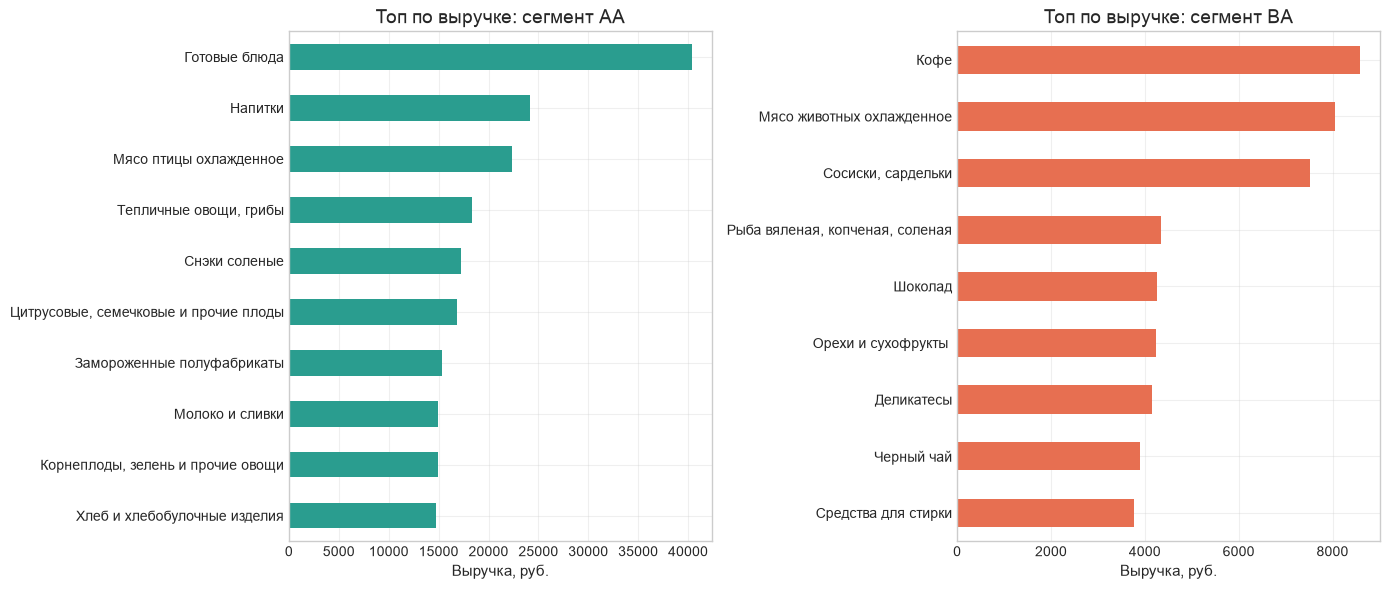

In [44]:
aa_top = (
    abc_matrix[abc_matrix['segment'] == 'AA']
    .sort_values('revenue', ascending=True)
    .tail(10)
)

ba_top = (
    abc_matrix[abc_matrix['segment'] == 'BA']
    .sort_values('revenue', ascending=True)
    .tail(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_chart(
    aa_top,
    kind='barh',
    x='subcategory',
    y='revenue',
    title='Топ по выручке: сегмент AA',
    xlabel='Выручка, руб.',
    color='#2A9D8F',
    ax=axes[0],
    show=False,
)

plot_chart(
    ba_top,
    kind='barh',
    x='subcategory',
    y='revenue',
    title='Топ по выручке: сегмент BA',
    xlabel='Выручка, руб.',
    color='#E76F51',
    ax=axes[1],
    show=False,
)

plt.tight_layout()
plt.show()

#### Вывод

- По матрице сегментов больше всего подкатегорий в `CC` (**32**) и `AA` (**23**). То есть картина типичная: есть ядро драйверов и длинный хвост слабых позиций.
- `AA` — главный приоритет. Там и штуки, и деньги. В топе по выручке, например, `готовые блюда`, `напитки`, `мясо птицы`, `тепличные овощи/грибы`, `солёные снэки`. Их наличие лучше контролировать в первую очередь.
- Сегмента `CA` за этот день нет. Близкий по смыслу `BA` (**9** подкатегорий): объём не максимальный, но выручка заметная — например, `кофе`, `охлаждённое мясо животных`, `сосиски/сардельки`.
- `AC` почти пустой (**2** подкатегории): много штук при слабой выручке — `сухие блюда быстрого приготовления` и `товары для собак`.
- `CC` — самый большой сегмент, но решения по сокращению ассортимента только по одному дню принимать рано.
- В целом ABC здесь полезен как карта приоритетов: `AA`/`BA` держать в фокусе, `CC` смотреть отдельно на более длинном периоде.

### Итоговое резюме

Коротко по всем задачам за 13.01.2022:

1. **Объём по категориям.** Больше всего штук дали `Безалкогольные напитки` и `Молочная продукция`. Дальше идут повседневные категории вроде овощей, кулинарии, бакалеи.
2. **Внутри категорий.** Структура разная: где-то продажи размазаны (`бакалея`, `напитки`, `молочка`), где-то один лидер почти на всю категорию.
3. **Средний чек.** 915.64 руб. по 544 заказам из `orders`.
4. **Промо в сырах.** Около `30.7%` штук и `23.19% `выручки шли по цене ниже регулярной.
5. **Маржа.** По рублям сильнее крупные категории (`напитки`, `кулинария`, `заморозка`, `молочка`).
6. **ABC по подкатегориям.** Ядро — сегмент `AA` (23 подкатегории). Самый большой хвост — `CC` (32). Сегмента `CA` за день не было.

Ограничение всего анализа: один день. Для управленческих решений лучше перепроверить на неделе/месяце.